In [1]:
from asmcmc.initialize import RandomLatticeInitializer, ColumnarLatticeInitializer, FrameInitializer
from asmcmc.metropolis import MetropolisCalculator
from asmcmc.potentials import GBQPotential, CACELLI_POTENTIAL
from asmcmc.measurements import (
    TrajectoryAnalyzer, 
    RadialDistributionFunction, 
    OrientationalCorrelationFunction, 
    HeatCapacity, 
    NematicOrderParameter, 
    AverageEnthalpy,
    BOLTZCONST
)

import pickle
import os
import json

import matplotlib.pyplot as plt
import numpy as np

from ase.db import connect
import ase.io

In [2]:
RESULTS_PATH_1 = "../results/validation/100.0_6.324209e-07/herringbone"
RESULTS_PATH_2 = "../results/validation/100.0_6.324209e-07/herringbone_jittered"
RESULTS_PATH_3 = "../results/validation/100.0_6.324209e-07/herringbone_jittered_2"

PKL_PATH_1 = f"{RESULTS_PATH_1}/measurements.pkl"
PKL_PATH_2 = f"{RESULTS_PATH_2}/measurements.pkl"
PKL_PATH_3 = f"{RESULTS_PATH_3}/measurements.pkl"

with open(PKL_PATH_1, "rb") as f:
    results_1 = pickle.load(f)

with open(PKL_PATH_2, "rb") as f:
    results_2 = pickle.load(f)

with open(PKL_PATH_3, "rb") as f:
    results_3 = pickle.load(f)

print(results_1.keys())

dict_keys(['rdf', 'ocf', 'nematic', 'enthalpy', 'heat_capacity'])


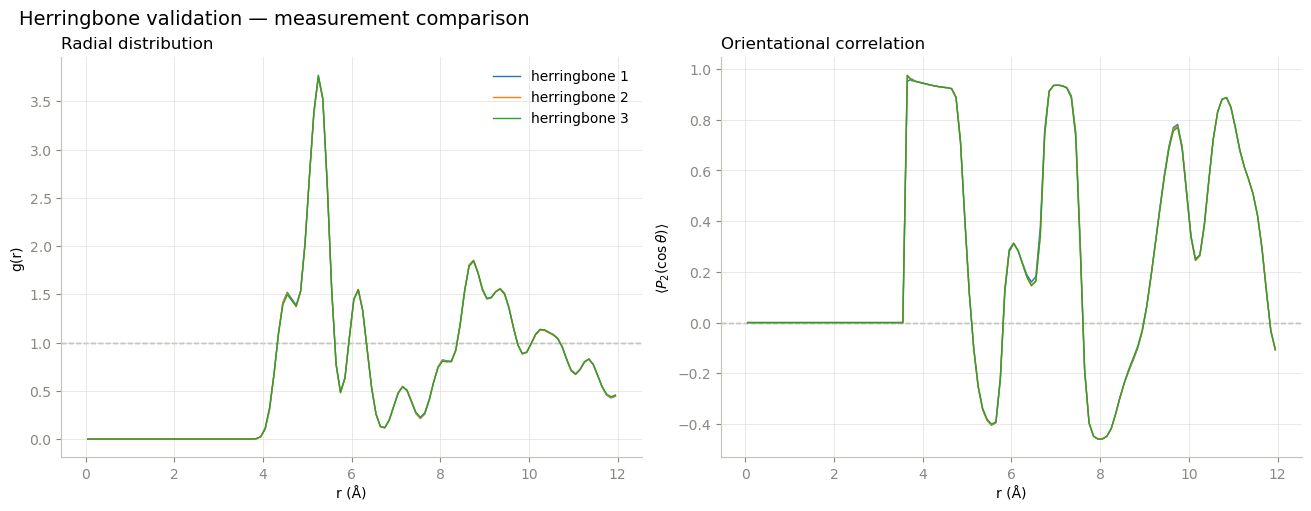

In [3]:
# Compare the measurements of the two herringbone validation runs.
# Fixed color -> run mapping (colorblind-safe categorical slots 1 & 2).
RUNS = [
    ("herringbone 1", results_1),
    ("herringbone 2", results_2),
    ("herringbone 3", results_3),
]

# recessive chart chrome
GRID, AXIS, MUTED = "#e1e0d9", "#c3c2b7", "#898781"

fig, (ax_rdf, ax_ocf) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# --- radial distribution function g(r): positional order ---
for label, res in RUNS:
    ax_rdf.plot(res["rdf"]["r"], res["rdf"]["g_r"], lw=1, label=label)
ax_rdf.axhline(1.0, lw=1, ls="--", color=MUTED, zorder=0)
ax_rdf.set_xlabel("r (Å)")
ax_rdf.set_ylabel("g(r)")
ax_rdf.set_title("Radial distribution", loc="left")
ax_rdf.legend(frameon=False)

# --- orientational correlation <P2(cos θ)>(r): orientational order ---
for label, res in RUNS:
    ax_ocf.plot(res["ocf"]["r"], res["ocf"]["s2_r"], lw=1, label=label)
ax_ocf.axhline(0.0, lw=1, ls="--", color=MUTED, zorder=0)
ax_ocf.set_xlabel("r (Å)")
ax_ocf.set_ylabel(r"$\langle P_2(\cos\theta)\rangle$")
ax_ocf.set_title("Orientational correlation", loc="left")

# recessive chrome everywhere
for a in (ax_rdf, ax_ocf):
    a.grid(True, color=GRID, lw=0.5)
    a.set_axisbelow(True)
    for spine in ("top", "right"):
        a.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        a.spines[spine].set_color(AXIS)
    a.tick_params(colors=MUTED)

fig.suptitle("Herringbone validation — measurement comparison",
             fontsize=14, x=0.01, ha="left")
plt.show()


In [4]:
# Derive the scalar comparisons from each run. Density, unit-cell lattice
# constants, and enthalpy of vaporization come from the trajectory (volume,
# box, particle count); S, H, and C_p reuse the stored measurements. Reads both
# simulation.db files, so it takes a moment.
from asmcmc.initialize import HerringboneLatticeInitializer

TEMP = 100.0            # K, the validation state point
M_BENZENE = 78.11       # g/mol per coarse-grained molecule (benzene)
N_AVOGADRO = 6.02214076e23
EV_TO_KJ_PER_MOL = 96.485
KT = BOLTZCONST * TEMP  # eV

def run_scalars(results_path, results):
    vols, lengths, n = [], [], None
    with connect(f"{results_path}/simulation.db") as db:
        for row in db.select():
            if n is None:
                n = row.natoms
            vols.append(row.volume)
            lengths.append(np.linalg.norm(np.asarray(row.cell), axis=1))
    v_mean = float(np.mean(vols))            # Å^3, trajectory-averaged volume
    box_edges = np.mean(lengths, axis=0)     # Å, mean box edge lengths

    # Unit-cell lattice constants. The box is a supercell of the 4-molecule Pbca
    # cell, so divide each box edge by its supercell reps. The initializer tiles
    # the motif in the experimental cell's (c, a, b) order, so reindex [1, 2, 0]
    # to the experimental (a, b, c) lineage before comparing to Cacelli Table V
    # (otherwise a is silently compared against their c, etc.).
    reps = np.array(HerringboneLatticeInitializer(n_particles=n).reps)
    a, b, c = (box_edges / reps)[[1, 2, 0]]

    # mass density: N molecules * molecular mass / volume
    density = n * M_BENZENE / (N_AVOGADRO * v_mean * 1e-24)  # g/cm^3

    # Enthalpy of vaporization per molecule: H_vapor - H_liquid. <H>/N is the
    # per-molecule enthalpy (P·V negligible at 1 atm); the ideal vapor gives
    # H_vapor/N = kT, so ΔH_vap = kT - <H>/N.
    h_total, h_std = results["enthalpy"]
    h_per = h_total / n
    dHvap = (KT - h_per) * EV_TO_KJ_PER_MOL             # kJ/mol
    dHvap_err = (h_std / n) * EV_TO_KJ_PER_MOL

    return {
        "n": n,
        "rho": density,                                 # g/cm^3
        "HN": h_per, "HN_err": h_std / n,               # eV per molecule
        "dHvap": dHvap, "dHvap_err": dHvap_err,         # kJ/mol
        "S": results["nematic"]["S"], "S_err": results["nematic"]["S_std"],
        "Cp": results["heat_capacity"] / BOLTZCONST,    # C_p / k_B
        "abc": (a, b, c),                               # Å, experimental (a, b, c) lineage
    }

scalars_1 = run_scalars(RESULTS_PATH_1, results_1)
scalars_2 = run_scalars(RESULTS_PATH_2, results_2)
scalars_3 = run_scalars(RESULTS_PATH_3, results_3)
for name, s in [("herringbone 1", scalars_1), ("herringbone 2", scalars_2), ("herringbone 3", scalars_3)]:
    print(name, {k: (np.round(v, 4) if np.ndim(v) == 0 else np.round(v, 3)) for k, v in s.items()})


herringbone 1 {'n': np.int64(400), 'rho': np.float64(1.3437), 'HN': np.float64(-0.4622), 'HN_err': np.float64(0.0008), 'dHvap': np.float64(45.4274), 'dHvap_err': np.float64(0.0746), 'S': np.float64(0.2893), 'S_err': np.float64(0.0101), 'Cp': np.float64(6.2162), 'abc': array([8.752, 6.152, 7.171])}
herringbone 2 {'n': np.int64(400), 'rho': np.float64(1.3436), 'HN': np.float64(-0.4622), 'HN_err': np.float64(0.0008), 'dHvap': np.float64(45.4285), 'dHvap_err': np.float64(0.0735), 'S': np.float64(0.2884), 'S_err': np.float64(0.0098), 'Cp': np.float64(6.1245), 'abc': array([8.752, 6.15 , 7.174])}
herringbone 3 {'n': np.int64(400), 'rho': np.float64(1.3436), 'HN': np.float64(-0.4622), 'HN_err': np.float64(0.0008), 'dHvap': np.float64(45.4292), 'dHvap_err': np.float64(0.0728), 'S': np.float64(0.2874), 'S_err': np.float64(0.0096), 'Cp': np.float64(6.0664), 'abc': array([8.75 , 6.15 , 7.176])}


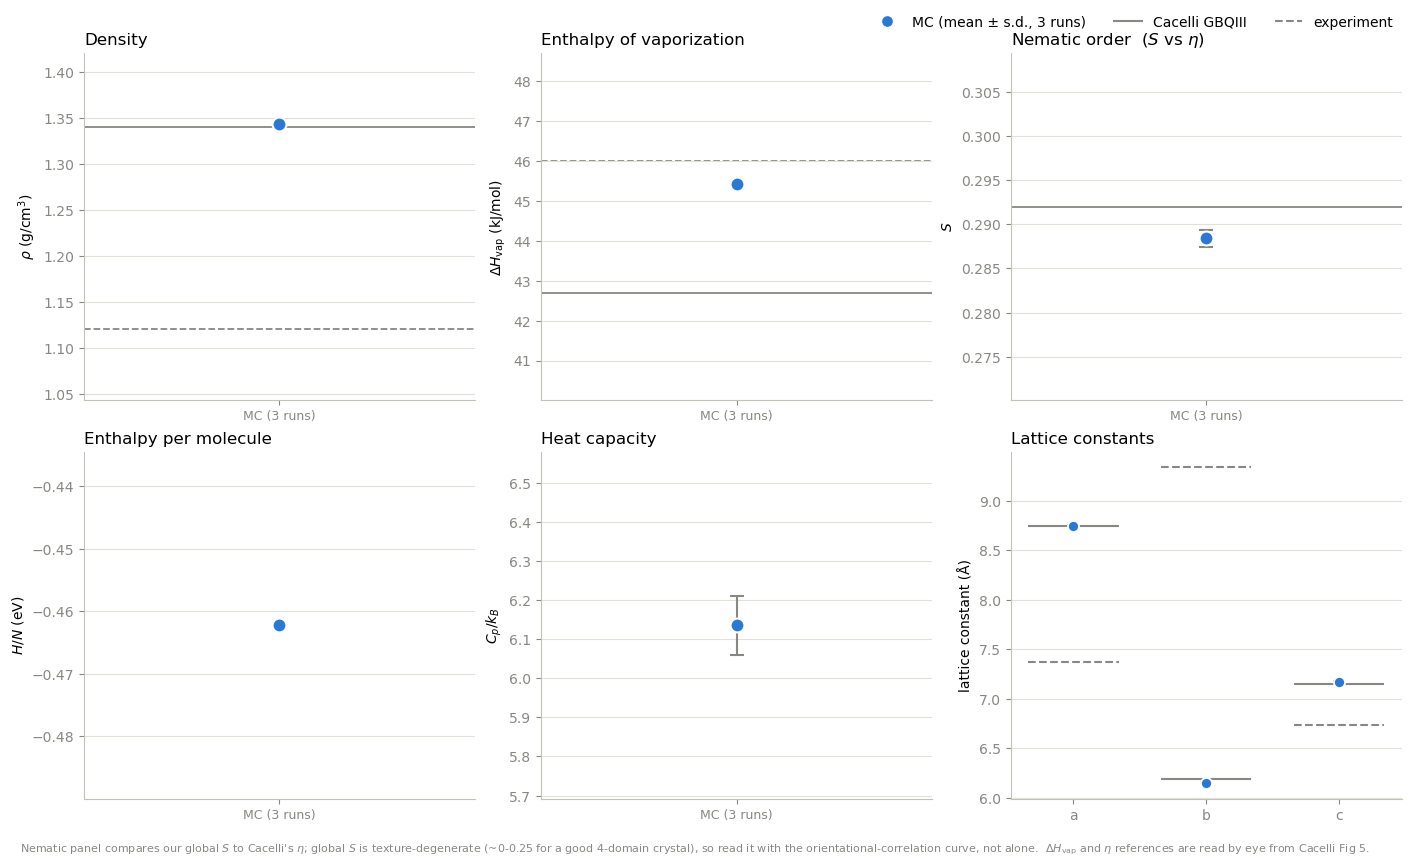

In [5]:
# Scalar measurements vs published references, aggregated over the three
# herringbone replicas. Each observable is one point at the mean over the runs
# with an error bar = sample std across the three runs; Cacelli GBQIII (2004) is
# a solid gray reference line and experiment a dashed gray line. Axes auto-zoom
# to the data with a floor. Run the run_scalars cell above first.
from matplotlib.lines import Line2D

RUN_SCALARS = [scalars_1, scalars_2, scalars_3]
N_RUNS = len(RUN_SCALARS)
MARKER = "#2a78d6"
GRID, AXIS, MUTED, REFLINE = "#e1e0d9", "#c3c2b7", "#898781", "#898781"

def agg(key):
    """Mean and sample std (across the replicas) of a per-run scalar or vector."""
    vals = np.array([s[key] for s in RUN_SCALARS])
    return vals.mean(axis=0), vals.std(axis=0, ddof=1)

# Published values (Cacelli et al. 2004): Table V for ρ and lattice constants,
# Fig 5 (read by eye) for ΔH_vap; the nematic reference is their order parameter
# η. Keys match run_scalars; a key absent from a dict means no published value
# for that observable (so no reference line is drawn).
REFERENCES = {
    "Cacelli GBQIII": {"rho": 1.34, "dHvap": 42.7, "S": 0.292, "abc": (8.75, 6.19, 7.15)},
    "experiment":     {"rho": 1.12, "dHvap": 46.0,             "abc": (7.37, 9.34, 6.74)},
}
REF_STYLE = {
    "Cacelli GBQIII": dict(ls="-",  color=REFLINE),
    "experiment":     dict(ls="--", color=REFLINE),
}

def style(ax):
    ax.grid(True, axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=MUTED)

def pad_ylim(ax, values):
    """Zoom to the data with a floor, so near-identical points aren't over-magnified."""
    lo, hi = np.min(values), np.max(values)
    m = max(0.18 * (hi - lo), 0.06 * abs(np.mean(values)), 1e-9)
    ax.set_ylim(lo - m, hi + m)

# (scalar key, title, ylabel) -- single-value panels
PANELS = [
    ("rho",   "Density",                        r"$\rho$ (g/cm$^3$)"),
    ("dHvap", "Enthalpy of vaporization",       r"$\Delta H_\mathrm{vap}$ (kJ/mol)"),
    ("S",     "Nematic order  ($S$ vs $\\eta$)", r"$S$"),
    ("HN",    "Enthalpy per molecule",          r"$H/N$ (eV)"),
    ("Cp",    "Heat capacity",                  r"$C_p / k_B$"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (key, title, ylabel) in zip(axes, PANELS):
    m, sd = agg(key)
    ax.errorbar(0.0, m, yerr=sd, fmt="o", ms=10, color=MARKER, mec="white",
                mew=1.5, ecolor=MUTED, elinewidth=1.5, capsize=5, zorder=3)
    yvals = [m - sd, m + sd]
    for name, refs in REFERENCES.items():
        if key in refs:
            ax.axhline(refs[key], lw=1.3, zorder=0, **REF_STYLE[name])
            yvals.append(refs[key])
    pad_ylim(ax, yvals)
    ax.set_xlim(-1, 1)
    ax.set_xticks([0.0])
    ax.set_xticklabels([f"MC ({N_RUNS} runs)"], fontsize=9)
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)
    style(ax)

# --- lattice constants a, b, c: replica mean ± s.d. + reference segments ---
ax = axes[5]
groups = np.arange(3)
m_abc, sd_abc = agg("abc")
ax.errorbar(groups, m_abc, yerr=sd_abc, fmt="o", ms=8, color=MARKER, mec="white",
            mew=1.3, ecolor=MUTED, elinewidth=1.5, capsize=4, zorder=3, ls="none")
for name, refs in REFERENCES.items():
    for g, val in zip(groups, refs["abc"]):
        ax.hlines(val, g - 0.34, g + 0.34, lw=1.5, zorder=0, **REF_STYLE[name])
ax.set_xticks(groups)
ax.set_xticklabels(["a", "b", "c"])
ax.set_title("Lattice constants", loc="left")
ax.set_ylabel("lattice constant (Å)")
style(ax)

# --- shared legend: aggregated run marker + reference line styles ---
handles = [
    Line2D([0], [0], marker="o", color=MARKER, mec="white", mew=1.3, ms=9,
           ls="none", label=f"MC (mean ± s.d., {N_RUNS} runs)")
] + [
    Line2D([0], [0], color=REFLINE, ls=REF_STYLE[n]["ls"], lw=1.5, label=n)
    for n in REFERENCES
]
fig.legend(handles=handles, frameon=False, loc="upper right",
           bbox_to_anchor=(1.0, 1.03), ncol=3)

# fig.suptitle("Herringbone validation — scalars vs Cacelli GBQIII & experiment",
#             fontsize=13, x=0.01, ha="left")
fig.text(0.01, -0.02,
         "Nematic panel compares our global $S$ to Cacelli's "
         "$\\eta$; global $S$ is texture-degenerate (~0-0.25 for a good 4-domain "
         "crystal), so read it with the orientational-correlation curve, not alone.  "
         "$\\Delta H_\\mathrm{vap}$ and $\\eta$ references are read by eye from Cacelli Fig 5.",
         fontsize=8, color=MUTED, ha="left", va="top")
plt.show()


In [6]:
# Table-V-style comparison: our two runs alongside the published references, the
# exact numbers behind the figure above. "—" = no published value. Reuses
# REFERENCES from the figure cell, so run that first.
import pandas as pd

RUNS_T = [("herringbone", scalars_1), ("herringbone (jittered)", scalars_2)]
REF_T = list(REFERENCES.items())

def _cell(val, fmt):
    return fmt.format(val) if val is not None else "—"

table = {}

def add_row(label, key, fmt):
    table[label] = ([_cell(s[key], fmt) for _, s in RUNS_T]
                    + [_cell(refs.get(key), fmt) for _, refs in REF_T])

add_row("ρ (g/cm³)",       "rho",   "{:.3f}")
add_row("H/N (eV)",        "HN",    "{:.3f}")   # intensive energy; no published value
add_row("ΔH_vap (kJ/mol)", "dHvap", "{:.1f}")
add_row("S / η",           "S",     "{:.3f}")
add_row("C_p / k_B",       "Cp",    "{:.2f}")   # no published value
# lattice constants: unpack the (a, b, c) tuple into three rows
for i, label in enumerate(("a (Å)", "b (Å)", "c (Å)")):
    table[label] = ([f"{s['abc'][i]:.2f}" for _, s in RUNS_T]
                    + [f"{refs['abc'][i]:.2f}" if "abc" in refs else "—" for _, refs in REF_T])

cols = [name for name, _ in RUNS_T] + [name for name, _ in REF_T]
df = pd.DataFrame.from_dict(table, orient="index", columns=cols)
df.index.name = "observable"
df


,herringbone,herringbone (jittered),Cacelli GBQIII,experiment
observable,,,,
ρ (g/cm³),1.344,1.344,1.340,1.120
H/N (eV),-0.462,-0.462,—,—
ΔH_vap (kJ/mol),45.4,45.4,42.7,46.0
S / η,0.289,0.288,0.292,—
C_p / k_B,6.22,6.12,—,—
a (Å),8.75,8.75,8.75,7.37
b (Å),6.15,6.15,6.19,9.34
c (Å),7.17,7.17,7.15,6.74
